In [63]:
! pip install scipy pandas tqdm seaborn emcee

In [64]:
import scipy.io as sio
from scipy.stats import norm
import seaborn as sns
cmap = sns.color_palette('rocket', n_colors=15)

import matplotlib.pyplot as plt
plt.style.use('ggplot')

import numpy as np
import pandas as pd
from emcee.autocorr import integrated_time

#from eprank import epr, epr_gen
from gibbsrank import gibbs_sample



In [65]:
import scipy.io as sio
import pandas as pd

# data loading
file_path = 'tennis_data.mat'
data = sio.loadmat(file_path)

print("Keys in MATLAB file:", data.keys())

players = data['W'].flatten()  # player names (W matrix)
games = data['G']              # game outcomes (G matrix)
df_players = pd.DataFrame(players, columns=['Player'])
df_games = pd.DataFrame(games, columns=['Winner', 'Loser'])
# adding player names
df_games['Winner_Name'] = df_games['Winner'].apply(lambda x: players[x - 1])
df_games['Loser_Name'] = df_games['Loser'].apply(lambda x: players[x - 1])


df_players.to_csv('players.csv', index=False)
df_games.to_csv('games.csv', index=False)


Keys in MATLAB file: dict_keys(['__header__', '__version__', '__globals__', 'W', 'G'])


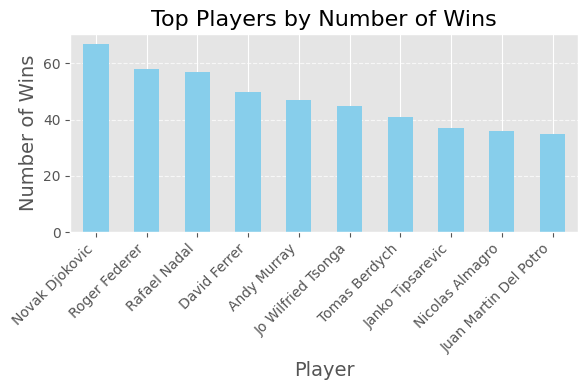

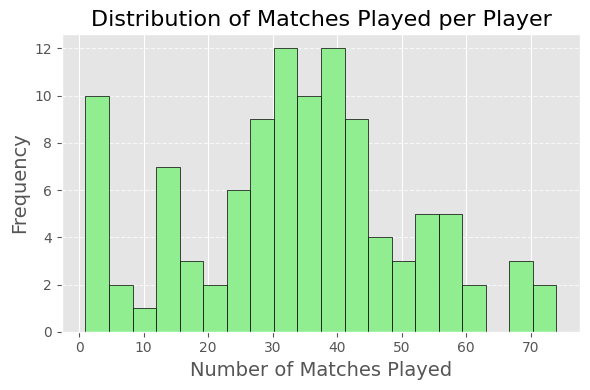

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

df_games = pd.read_csv('games.csv')

# brackets in names removed because annoying
df_games['Winner_Name'] = df_games['Winner_Name'].str.strip('[]').str.replace('-', ' ').str.replace("'", '')
df_games['Loser_Name'] = df_games['Loser_Name'].str.strip('[]').str.replace('-', ' ').str.replace("'", '')

# top players, no. of win
top_winners = df_games['Winner_Name'].value_counts().head(10)
plt.figure(figsize=(6, 4))
top_winners.plot(kind='bar', color='skyblue')
plt.title('Top Players by Number of Wins', fontsize=16)
plt.xlabel('Player', fontsize=14)
plt.ylabel('Number of Wins', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# matches played dist.
df_matches = pd.concat([df_games['Winner_Name'], df_games['Loser_Name']])
match_counts = df_matches.value_counts()
plt.figure(figsize=(6, 4))
match_counts.hist(bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Matches Played per Player', fontsize=16)
plt.xlabel('Number of Matches Played', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




In [67]:
import matplotlib.pyplot as plt
import numpy as np

def sorted_barplot(P, W, E=None, color='blue'):
    """
    Function for making a sorted bar plot based on values in P, and labelling the plot with the
    corresponding names
    P: An array of length num_players (107), W: Array containing names of each player, E: Error values for the bars (optional), color: Color for the bars (default is 'blue')
    """
    M = len(P)
    xx = np.linspace(0, M, M)
    plt.figure(figsize=(20, 20))
    sorted_indices = np.argsort(P)
    sorted_names = W[sorted_indices]
    plt.barh(xx, P[sorted_indices], xerr=E, color=color)
    plt.yticks(np.linspace(0, M, M), labels=sorted_names[:, 0])
    plt.ylim([-2, 109])
    plt.show()

### EP for TrueSkill

**Marginal skill beliefs**

$$P_s[p] = \sigma_0^{-2} + \sum_{g \in G_w(p)} P_{gs}[g,0] + \sum_{g \in G_l(p)} P_{gs}[g,1]$$

$$M_s[p] = P_s[p]^{-1}\left(\sum_{g \in G_w(p)} P_{gs}[g,0]\, M_{gs}[g,0] + \sum_{g \in G_l(p)} P_{gs}[g,1]\, M_{gs}[g,1]\right)$$

$\sigma_0^2 = 0.5$. $G_w, G_l$ = games won/lost.

**Cavity (skill to game)**

$$P_{sg}[g,:] = P_s[G[g,:]] - P_{gs}[g,:]$$

$$M_{sg}[g,:] = \frac{P_s[G[g,:]] \, M_s[G[g,:]] - P_{gs}[g,:] \, M_{gs}[g,:]}{P_{sg}[g,:]}$$

**Performance difference**

$$v_g = 1 + P_{sg}[g,0]^{-1} + P_{sg}[g,1]^{-1}, \qquad m_g = M_{sg}[g,0] - M_{sg}[g,1]$$

**Moment matching** — $\psi(x) = \phi(x)/\Phi(x)$, $\lambda(x) = \psi(x)(\psi(x) + x)$

$$M_t = m_g + \sqrt{v_g}\;\psi\!\left(\frac{m_g}{\sqrt{v_g}}\right), \qquad P_t = \frac{1}{v_g\left(1 - \lambda\!\left(\frac{m_g}{\sqrt{v_g}}\right)\right)}$$

**Perf to game messages**

$$P_{tg} = P_t - v_g^{-1}, \qquad M_{tg} = \frac{M_t P_t - m_g v_g^{-1}}{P_{tg}}$$

**Game to skill messages**

$$P_{gs}[g,:] = \left(1 + P_{tg}^{-1} + P_{sg}[g,:]^{-1}\right)^{-1}$$

$$M_{gs}[g,:] = \begin{bmatrix} M_{tg} \\ -M_{tg} \end{bmatrix} + \begin{bmatrix} M_{sg}[g,1] \\ M_{sg}[g,0] \end{bmatrix}$$

Iterate until $M_s$, $P_s$ converge.

In [68]:
import numpy as np
from tqdm import tqdm


def epr(G, M, num_iters):
    """Run EP ranking to convergence, return final (Ms, Ps)."""
    gen = epr_gen(G, M, num_iters)
    for i in range(num_iters - 1):
        next(gen)
    return next(gen)


def epr_gen(G, M, num_iters):
    """EP message passing for TrueSkill-style ranking. Yields (Ms, Ps) each iteration."""
    N = G.shape[0]
    pv = 0.5  # prior variance (zero mean)

    psi = lambda x: norm.pdf(x) / norm.cdf(x)
    lam = lambda x: psi(x) * (psi(x) + x)

    # marginals
    Ms = np.zeros(M)
    Ps = np.zeros(M)

    # game <-> skill messages
    Mgs = np.zeros((N, 2))
    Pgs = np.zeros((N, 2))
    Msg = np.zeros((N, 2))
    Psg = np.zeros((N, 2))

    for iter in range(num_iters):
        # marginal skill beliefs
        for p in range(M):
            gw = np.where(G[:, 0] == p)[0]
            gl = np.where(G[:, 1] == p)[0]
            Ps[p] = 1./pv + np.sum(Pgs[gw, 0]) + np.sum(Pgs[gl, 1])
            Ms[p] = (np.sum(Pgs[gw, 0] * Mgs[gw, 0]) + np.sum(Pgs[gl, 1] * Mgs[gl, 1])) / Ps[p]

        # cavity
        Psg = Ps[G] - Pgs
        Msg = (Ps[G] * Ms[G] - Pgs * Mgs) / Psg

        # perf difference
        vgt = 1 + np.sum(1. / Psg, axis=1)
        mgt = Msg[:, 0] - Msg[:, 1]

        # moment matching
        Mt = mgt + np.sqrt(vgt) * psi(mgt / np.sqrt(vgt))
        Pt = 1. / (vgt * (1 - lam(mgt / np.sqrt(vgt))))

        # perf -> game
        ptg = Pt - 1. / vgt
        mtg = (Mt * Pt - mgt / vgt) / ptg

        # game -> skill
        Pgs = 1. / (1 + 1. / ptg[:, None] + 1. / np.flip(Psg, axis=1))
        Mgs = np.stack([mtg, -mtg], axis=1) + np.flip(Msg, axis=1)

        yield np.copy(Ms), np.copy(Ps)

In [69]:
np.random.seed(0)

data = sio.loadmat('tennis_data.mat')
W = data['W']  # player names
for i, player in enumerate(W):
    W[i] = player[0]
G = data['G'] - 1  # (N, 2) array: [winner, loser] per game, 0-indexed
M = W.shape[0]
N = G.shape[0]

### Gibbs Sampler for TrueSkill Ranking

**Model**

$$t_g = w_{I_g} - w_{J_g} + \epsilon_g, \quad \epsilon_g \sim \mathcal{N}(0,1), \quad t_g > 0$$

$$w_i \sim \mathcal{N}(0, \sigma^2)$$

Joint posterior: $p(w, t \mid G) \propto p(t \mid w)\, p(w) \cdot \mathbb{I}(t > 0)$

**Sampling $t_g \mid w$** — truncated Gaussian

$$t_g \mid w \sim \mathcal{N}(w_{I_g} - w_{J_g},\; 1) \quad \text{truncated to } t_g > 0$$

Rejection sample: draw from the untruncated distribution, reject if $\leq 0$.

**Sampling $w \mid t$** — conjugate Gaussian

Write $t = Aw + \eta$, $\eta \sim \mathcal{N}(0, I)$, where $A \in \mathbb{R}^{N \times M}$ is the game-player incidence matrix ($+1$ winner, $-1$ loser).

$$\Sigma^{-1} = A^\top A + \sigma^{-2} I, \qquad \mu = \Sigma A^\top t$$

$$w \mid t \sim \mathcal{N}(\mu, \Sigma)$$

Sample via Cholesky of $\Sigma^{-1}$.

**Complexity** — per iteration: $O(N + M^3)$. Cholesky dominates. Total for $T$ iterations: $O(T(N + M^3))$.

In [70]:
# number of iterations
num_iters = 1100
# perform gibbs sampling, skill samples is an num_players x num_samples array
skill_samples = gibbs_sample(G, M, num_iters)#, random_nums)


  0%|          | 0/1100 [00:00<?, ?it/s]

100%|██████████| 1100/1100 [00:15<00:00, 70.23it/s]


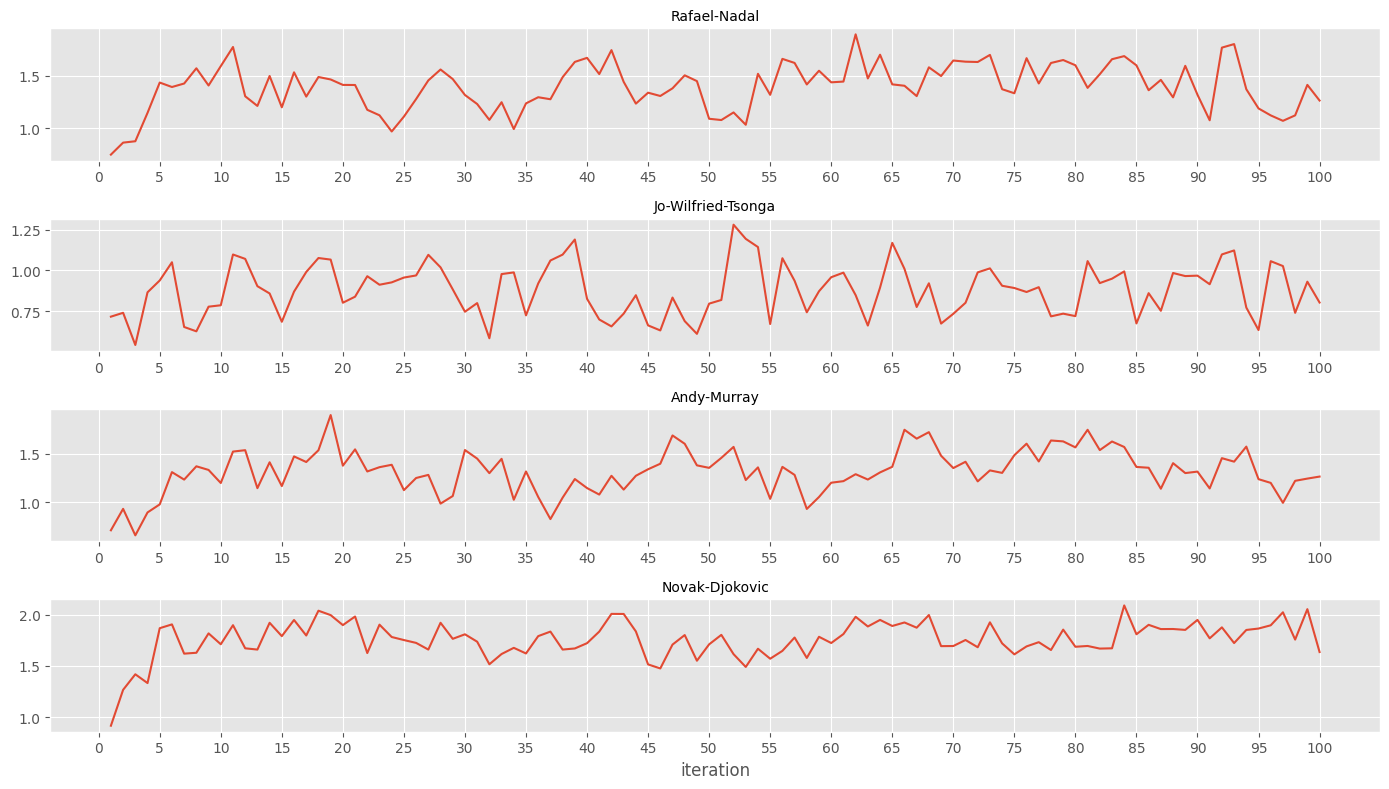

In [71]:
#plotting the skill for a number of players
fig, axs = plt.subplots(4, 1)
fig.set_figheight(8)
fig.set_figwidth(14)

for i, p in enumerate([0, 5, 10, 15]):
    axs[i].plot(range(1, 101), skill_samples[p, :100])
    axs[i].set_title(W[p][0], fontsize=10)
    axs[i].set_xticks(range(0, 101, 5))

axs[3].set_xlabel('iteration')

fig.tight_layout()
plt.show()

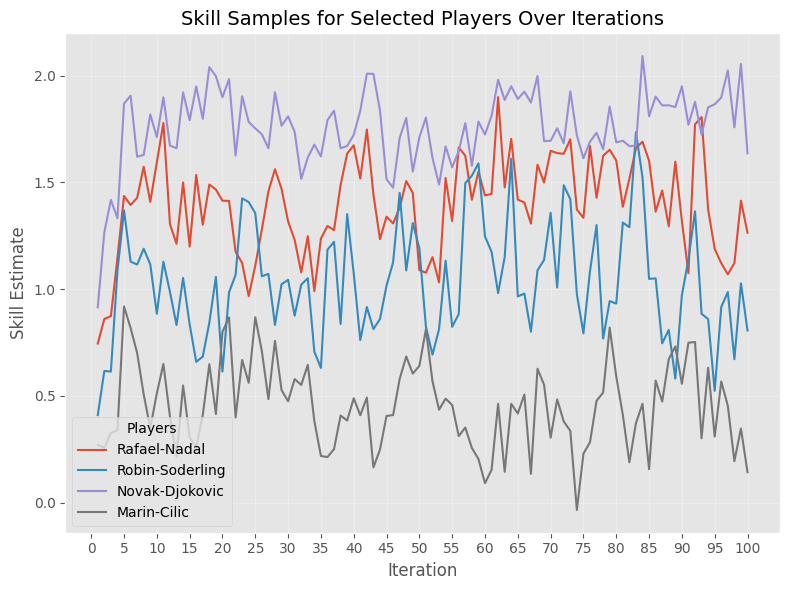

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

#players_to_plot = [0, 5, 10, 15]
players_to_plot = [0, 23, 15 , 25]
labels = [W[p][0] for p in players_to_plot]  # Assuming W contains player names

for i, p in enumerate(players_to_plot):
    ax.plot(range(1, 101), skill_samples[p, :100], label=labels[i])


ax.set_title("Skill Samples for Selected Players Over Iterations", fontsize=14)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Skill Estimate", fontsize=12)
ax.legend(title="Players", fontsize=10)
ax.set_xticks(range(0, 101, 5))
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()


Autocorrelation of Gibbs samples for player $p=5$, lags $0$–$10$. High autocorrelation = slow mixing.

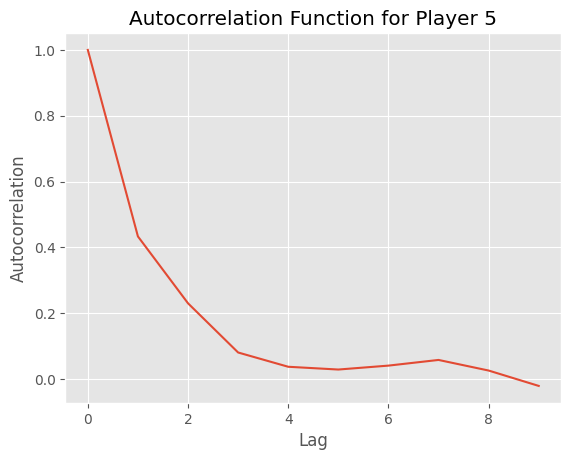

In [73]:
p = 5
autocor = np.zeros(10)
for i in range(10):
    series = pd.Series(skill_samples[p, :])
    autocor[i] = series.autocorr(lag=i)
plt.plot(autocor)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function for Player {}'.format(p))
plt.show()

Autocorrelation drops to near-zero by lag ~5. Mixing is fast for this player.

Suggests burn-in of ~5–10 iterations, thinning factor ~5 for approximate independence.

In [74]:
def logconditional_skills(G, w):
    # G represent the matrix of games
    
    prior = norm.pdf(w)
    outcome_p = np.array([w[p1] - w[p2] for (p1, p2) in G])
    outcome_p = norm.cdf(outcome_p)
    
    logconditional = np.sum(np.log(prior)) + np.sum(np.log(outcome_p))
    return logconditional

In [75]:
logconditionals = [logconditional_skills(G, w) for w in skill_samples.T]

Integrated autocorrelation time estimated via `emcee`. Thinning factor = $\lfloor \tau \rfloor + 1$, burn-in = 50.

In [76]:

# will be used to remove any correlation artefacts
ac_time = integrated_time(skill_samples.T, c = 10, tol = 50)[0]


thinning = int(ac_time) + 1

In [77]:
ac_time

np.float64(2.358257211610301)

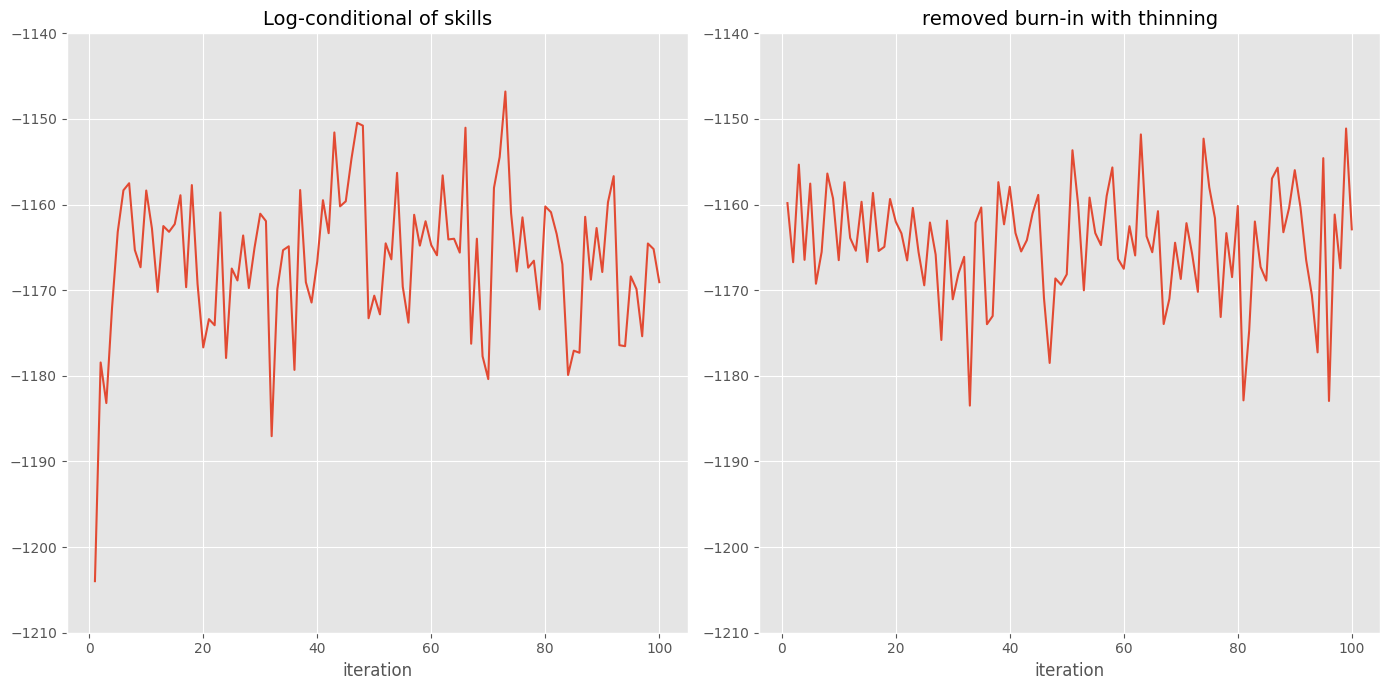

In [78]:
burn_in = 100

fig, axs = plt.subplots(1, 2)
fig.set_figheight(7)
fig.set_figwidth(14)

axs[0].plot(range(1, 101), logconditionals[:100])
axs[0].set_title("Log-conditional of skills", fontsize=14)
axs[0].set_xlabel('iteration')
axs[0].set_ylim(-1210, -1140)

axs[1].plot(range(1, 101), logconditionals[burn_in::thinning][:100])
axs[1].set_title("removed burn-in with thinning", fontsize=14)
axs[1].set_xlabel('iteration')
axs[1].set_ylim(-1210, -1140)

fig.tight_layout()
plt.show()

Left plot: raw log-conditional over first 100 iterations. Initial transient settles after ~10–20 iters, then fluctuates in stationary regime with visible autocorrelation.

Right plot: after burn-in (50) and thinning (factor 5). Cleaner trace, autocorrelation largely removed, values consistent with stationary phase. Confirms burn-in and thinning choices are reasonable.

In [79]:
#autocorrelation function for player p
corrlen = 15
autocor = np.zeros((M, corrlen))
for p in range(M):
    for i in range(corrlen):
        autocor[p, i] = pd.Series.autocorr(pd.Series(skill_samples[p, :]), lag=i)

autocor_bt = np.zeros((M, corrlen))
for p in range(M):
    for i in range(corrlen):
        autocor_bt[p, i] = pd.Series.autocorr(pd.Series(skill_samples[p, burn_in::thinning]), lag=i)

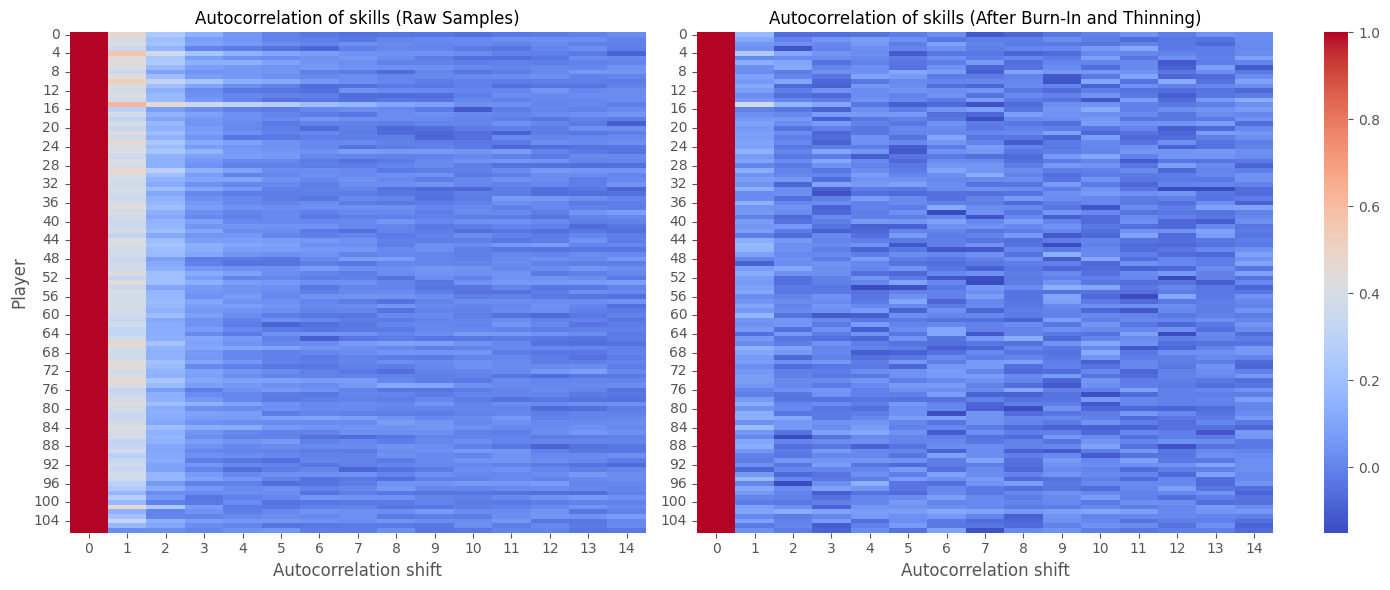

In [80]:
fig, (ax1, ax2, axcb2) = plt.subplots(1, 3, gridspec_kw = {'width_ratios':[0.96, 0.96, 0.04]})
fig.set_figheight(6)
fig.set_figwidth(14)

ax2.sharey(ax1)

new_cmap = "coolwarm"

g1 = sns.heatmap(autocor, cbar=False, ax = ax1, vmin = -0.15, vmax = 1.0, cmap = "coolwarm")
g1.set_ylabel('Player')
g1.set_xlabel('Autocorrelation shift')
g1.set_title("Autocorrelation of skills (Raw Samples)", fontsize=12)

g2 = sns.heatmap(autocor_bt, cbar=True, ax = ax2, cbar_ax = axcb2, vmin = -0.15, vmax = 1.0, cmap = "coolwarm")
g2.set_xlabel('Autocorrelation shift')
g2.set_title("Autocorrelation of skills (After Burn-In and Thinning)", fontsize=12)

fig.tight_layout()
plt.show()

### Convergence: Gibbs vs EP

**Gibbs**: converges when samples represent draws from $p(w \mid y)$, i.e. stationarity. Hard to verify rigorously since it's stochastic. Practical approach: run sampler from many random initialisations (400 runs × 20 iters), check mean and variance of skills stabilise across runs. Could also thin to get i.i.d. samples and apply diagnostics, but expensive.

**EP**: deterministic, so just track Gaussian parameters ($M_s$, $P_s$) across iterations. Converged when updates fall below some threshold.

Below: 400 independent Gibbs runs, plotting mean ± std of skills for players [0, 5, 10, 15] across iterations.

In [81]:
#iterations
c_iters, repeat = 25, 300

# gibbs sampling, skill samples is an num_players x num_samples array
convergence_samples = np.array([gibbs_sample(G, M, c_iters, random = True) for _ in range(repeat)])

100%|██████████| 25/25 [00:00<00:00, 73.76it/s]


In [82]:
# mean and standard deviation at each iteration for each player
convergence_mean = np.mean(convergence_samples, axis = 0)
convergence_stdd = np.std(convergence_samples, axis = 0)

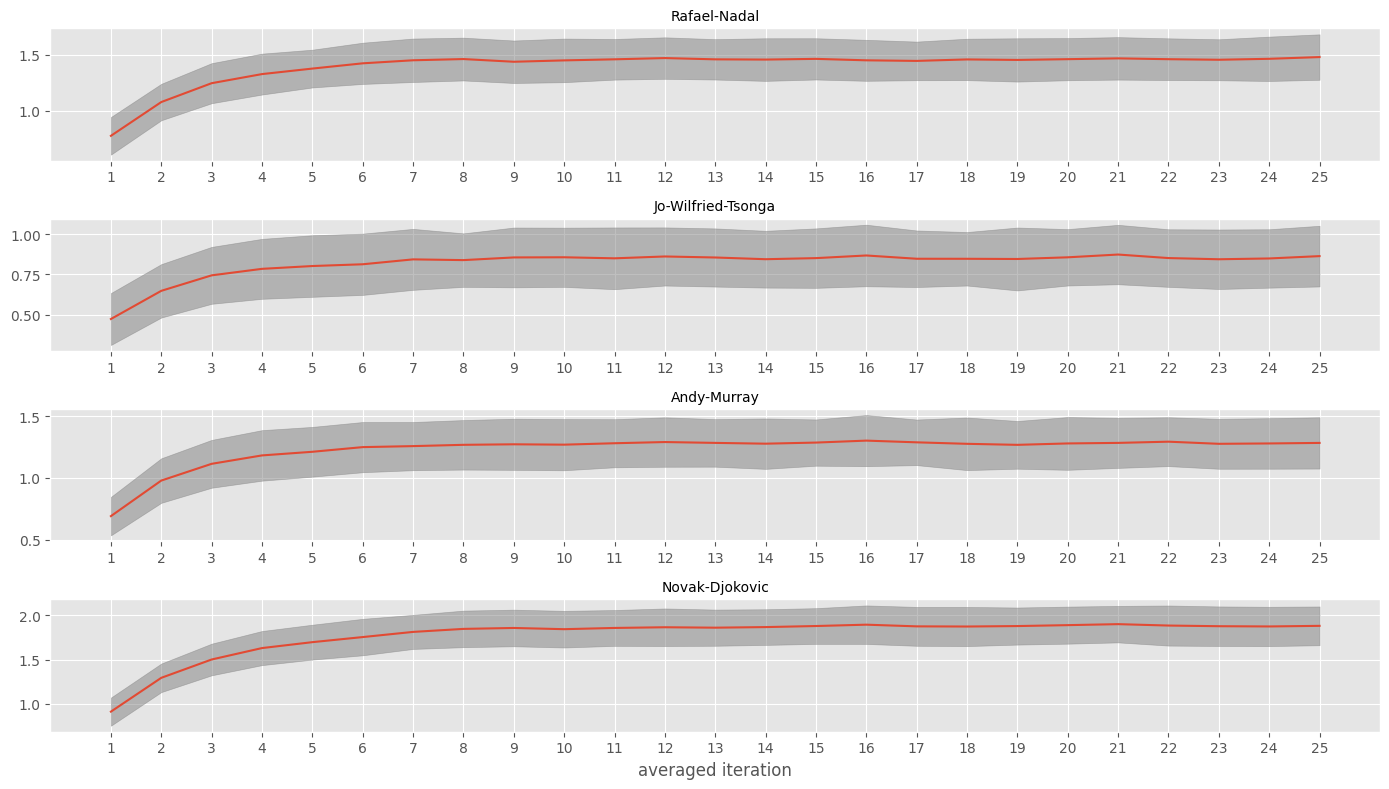

In [83]:
#plotting the skill for a number of players
fig, axs = plt.subplots(4, 1)
fig.set_figheight(8)
fig.set_figwidth(14)
for i, p in enumerate([0, 5, 10, 15]):
    axs[i].plot(range(1, c_iters+1), convergence_mean[p])
    axs[i].fill_between(range(1, c_iters+1), 
                        y1 = convergence_mean[p] + convergence_stdd[p], 
                        y2 = convergence_mean[p] - convergence_stdd[p],
                        alpha = 0.50,
                        color = 'grey')
    axs[i].set_title(W[p][0], fontsize=10)
    axs[i].set_xticks(range(1, c_iters + 1))

axs[-1].set_xlabel('averaged iteration')

fig.tight_layout()
plt.show()

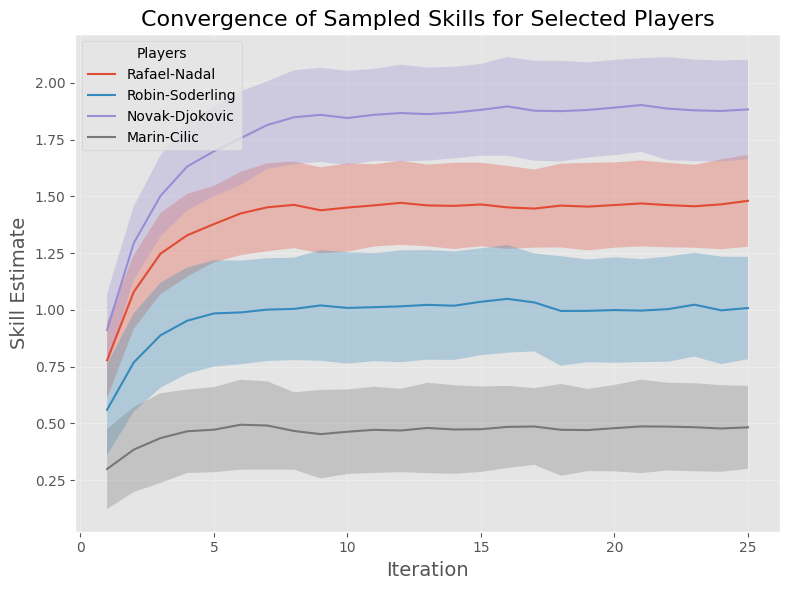

In [84]:

fig, ax = plt.subplots(figsize=(8, 6))
players_to_plot = [0, 23, 15 , 25]

# mean and uncertainty for each player
for p in players_to_plot:
    ax.plot(range(1, c_iters + 1), convergence_mean[p], label=f"{W[p][0]}")
    ax.fill_between(
        range(1, c_iters + 1), 
        y1=convergence_mean[p] + convergence_stdd[p], 
        y2=convergence_mean[p] - convergence_stdd[p],
        alpha=0.3
    )


ax.set_title("Convergence of Sampled Skills for Selected Players", fontsize=16)
ax.set_xlabel("Iteration", fontsize=14)
ax.set_ylabel("Skill Estimate", fontsize=14)
ax.legend(title="Players", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [85]:
def lp_difference(arr, p):
    diff = [np.linalg.norm(arr[:, i] - arr[:, i-1], ord = p) 
            for i in range(1, arr.shape[1])]
    return diff

In [86]:
num_iters = 200

# message passing algorithm, returns mean and precision for each player
gen = epr_gen(G, M, num_iters)


mean_player_skills = np.zeros((M, num_iters)) 
precision_player_skills = np.zeros((M, num_iters))

for i in range(num_iters):
    mps, pps = next(gen)
    mean_player_skills[:, i] = mps
    precision_player_skills[:, i] = pps

In [87]:
# convergence norm
p, plbl = 1, 'manhattan'

mean_diff = lp_difference(mean_player_skills, p)
precision_diff = lp_difference(precision_player_skills, p)

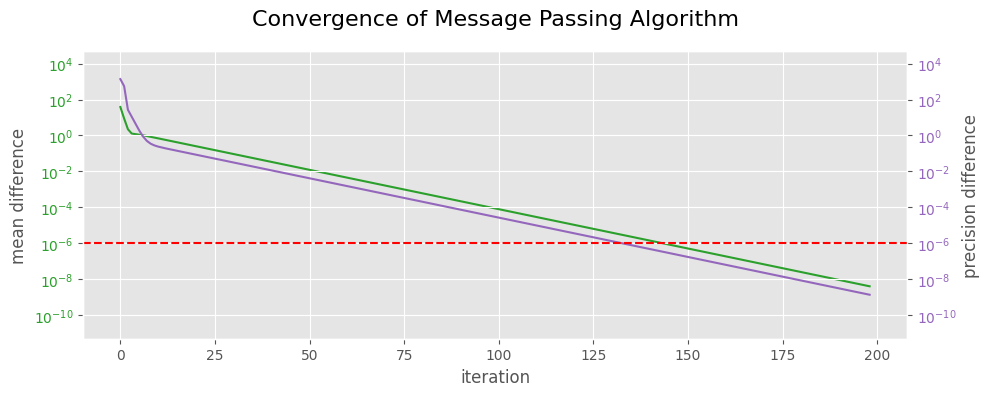

In [88]:
convergence_threshold = 1e-6

fig, ax1 = plt.subplots(1, 1)
fig.set_figheight(4)
fig.set_figwidth(10)

color = 'tab:green'
ax1.semilogy(mean_diff, color = color, label = 'mean')
ax1.tick_params(axis = 'y', labelcolor = color)
ax1.set_ylabel('mean difference')
ax1.set_xlabel('iteration')
ax1.set_ylim(5e-12, 5e4)

color = 'tab:purple'
ax2 = ax1.twinx()
ax2.semilogy(precision_diff, color = color, label = 'precision')
ax2.tick_params(axis = 'y', labelcolor = color)
ax2.set_ylabel('precision difference')
ax2.set_ylim(5e-12, 5e4)
plt.axhline(y=convergence_threshold, color='red', linestyle='--', label='Convergence Threshold')
fig.suptitle("Convergence of Message Passing Algorithm", fontsize=16)
fig.tight_layout()
plt.show()

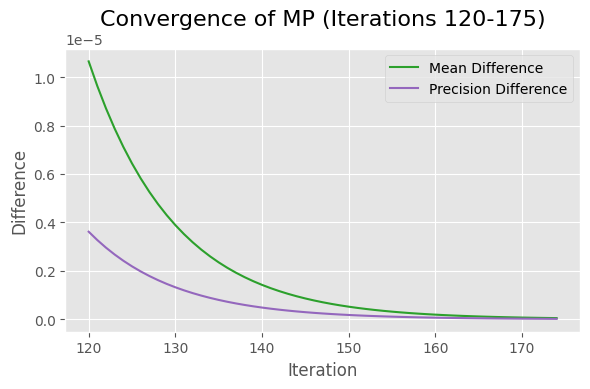

In [89]:
import matplotlib.pyplot as plt

convergence_threshold = 1e-6
start_iter = 120
end_iter = 175

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.plot(range(start_iter, end_iter), mean_diff[start_iter:end_iter], color='tab:green', label='Mean Difference')
ax1.plot(range(start_iter, end_iter), precision_diff[start_iter:end_iter], color='tab:purple', label='Precision Difference')


ax1.set_xlabel('Iteration')
ax1.set_ylabel('Difference')
ax1.set_title(f"Convergence of MP (Iterations {start_iter}-{end_iter})", fontsize=16)
ax1.legend()
fig.tight_layout()
plt.show()


### Skill difference and win probability

Skill difference: $z_{ij} = w_i - w_j$. Since $w_i \perp w_j \mid \mathbf{y}$:

$$z_{ij} \sim \mathcal{N}\left(\mu_i - \mu_j,\; \nu_i^{-1} + \nu_j^{-1}\right)$$

**(1) Prob. player $i$ more skilled than $j$:**

$$p(w_i > w_j) = p(z_{ij} > 0) = \Phi\left(\frac{\mu_i - \mu_j}{\sqrt{\nu_i^{-1} + \nu_j^{-1}}}\right)$$

In [90]:
def probability_higher_skill(skills, precis):
    skills = skills.reshape(1, -1)
    skills = skills - skills.T
    
    standr = 1/precis.reshape(1, -1)
    standr = np.sqrt(standr + standr.T)
    
    return norm.cdf(skills/standr)

**(2) Prob. player $i$ beats $j$ in a game:**

Performance difference $t_{ij} = w_i - w_j + \epsilon$, $\epsilon \sim \mathcal{N}(0,1)$. Player $i$ wins when $t_{ij} > 0$.

$$p(t_{ij} > 0) = \Phi\left(\frac{\mu_i - \mu_j}{\sqrt{\nu_i^{-1} + \nu_j^{-1} + 1}}\right)$$

Same form as (1) but with extra unit variance from the game noise.

In [91]:
def probability_winning_game(skills, precis):
    skills = skills.reshape(1, -1)
    skills = skills - skills.T
    
    standr = 1/precis.reshape(1, -1)
    standr = np.sqrt(standr + standr.T + 1)
    
    return norm.cdf(skills/standr)

In [92]:
# top 4 players 
top4 = np.array([15, 0, 4, 10])

print(W[top4].flatten())

['Novak-Djokovic' 'Rafael-Nadal' 'Roger-Federer' 'Andy-Murray']


In [93]:
# p(w_i > w_j) for top 4 players. Note: A + A.T = 1 (antisymmetric)
higher_skill_probability = probability_higher_skill(mps[top4], pps[top4])
higher_skill_probability.T.round(3)

array([[0.5  , 0.94 , 0.909, 0.985],
       [0.06 , 0.5  , 0.427, 0.767],
       [0.091, 0.573, 0.5  , 0.811],
       [0.015, 0.233, 0.189, 0.5  ]])

In [94]:
winning_game_probability = probability_winning_game(mps[top4], pps[top4])
winning_game_probability.T.round(3)

array([[0.5  , 0.655, 0.638, 0.72 ],
       [0.345, 0.5  , 0.482, 0.573],
       [0.362, 0.518, 0.5  , 0.591],
       [0.28 , 0.427, 0.409, 0.5  ]])

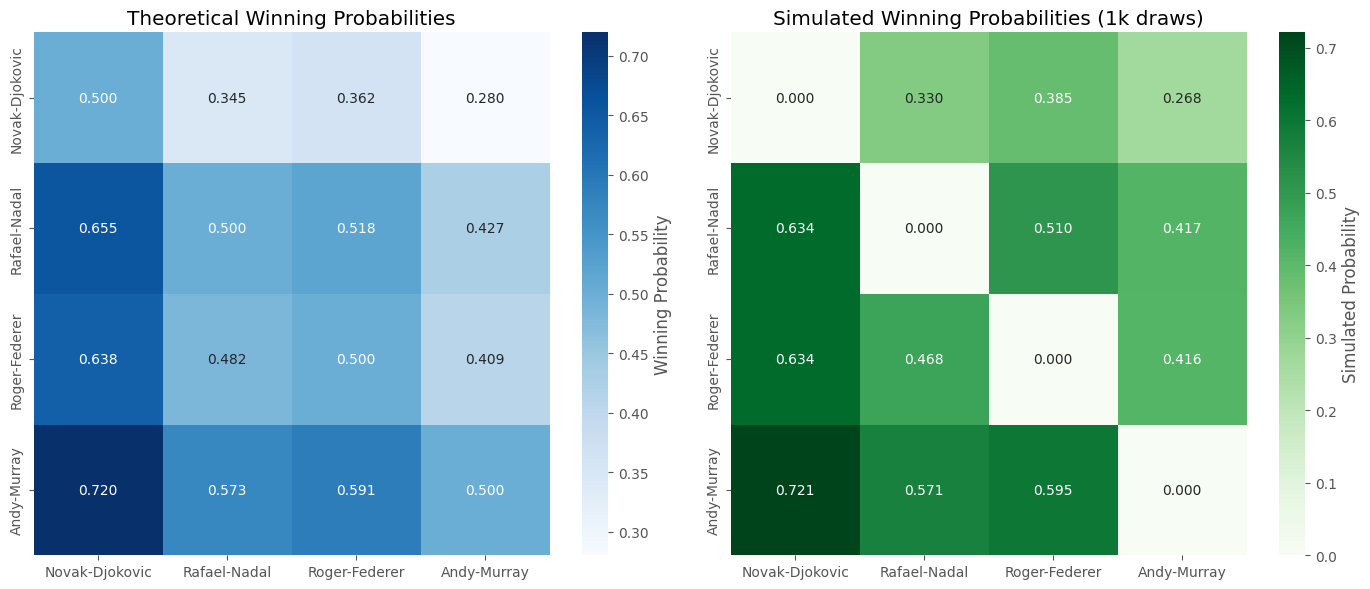

Theoretical:
 [[0.5   0.655 0.638 0.72 ]
 [0.345 0.5   0.482 0.573]
 [0.362 0.518 0.5   0.591]
 [0.28  0.427 0.409 0.5  ]]

Simulated:
 [[0.    0.634 0.634 0.721]
 [0.33  0.    0.468 0.571]
 [0.385 0.51  0.    0.595]
 [0.268 0.417 0.416 0.   ]]


In [95]:
def simulate_matches(prob_matrix, n_sims=1000):
    n = prob_matrix.shape[0]
    wins = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                wins[i, j] = np.sum(np.random.rand(n_sims) < prob_matrix[i, j])
    return wins

n_sims = 1000
simulated_probs = simulate_matches(winning_game_probability, n_sims) / n_sims

# theoretical vs simulated win probs
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
labels = W[top4].flatten()

sns.heatmap(winning_game_probability, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax[0],
            cbar_kws={"label": "Winning Probability"})
ax[0].set_title("Theoretical Winning Probabilities")

sns.heatmap(simulated_probs, annot=True, fmt=".3f", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=ax[1],
            cbar_kws={"label": "Simulated Probability"})
ax[1].set_title("Simulated Winning Probabilities (1k draws)")

plt.tight_layout()
plt.show()

print("Theoretical:\n", winning_game_probability.T.round(3))
print("\nSimulated:\n", simulated_probs.T.round(3))

# Gibbs Sampling Estimate

### Skill estimation from Gibbs samples

Three approaches: (1) fit independent Gaussians per player, (2) fit joint Gaussian over skills, (3) raw MC estimate from samples.

Gaussian fitting inflates variance due to outliers, e.g. smooths out Djokovic's skill estimate and lowers $p(\text{higher skill})$. MC estimate is more robust here — good justification for preferring Gibbs samples directly.

Below: Nadal vs Djokovic scatter with marginals, then estimation using thinned samples.

In [96]:
# rafa, fed
top2 = np.array([0,4])

print(W[top2].flatten())

['Rafael-Nadal' 'Roger-Federer']


In [97]:
players = np.array([4,0])

#  skills for nadal and federer removing transient phase and with thinning
thinned_skill_samples = skill_samples[players, burn_in::thinning]

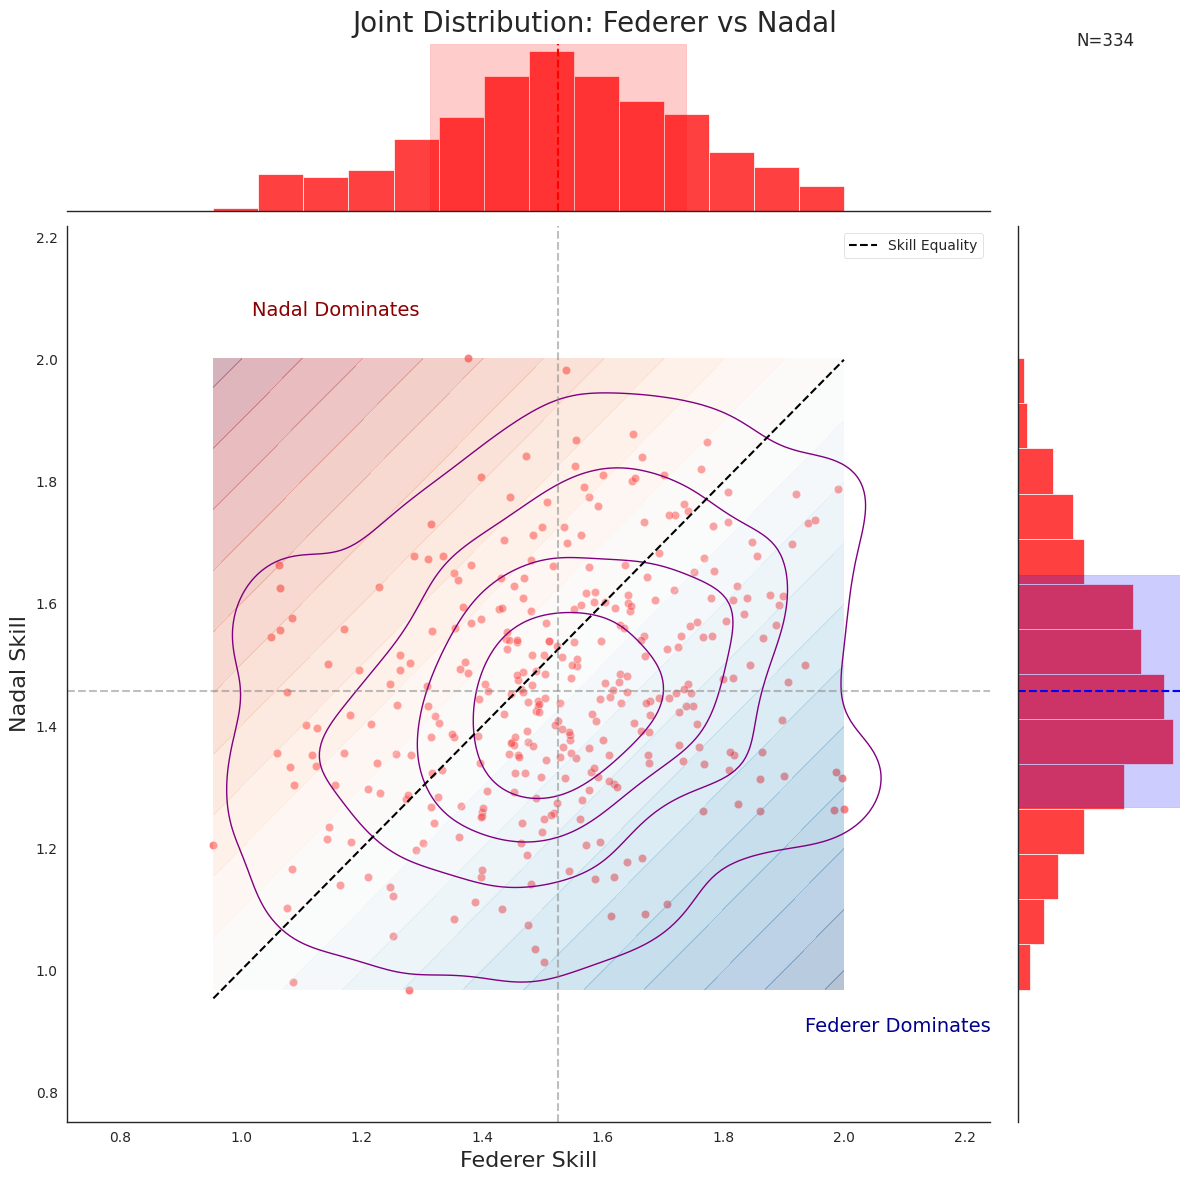

In [98]:
players = np.array([4, 0])  # Federer, Nadal
thinned = skill_samples[players, burn_in::thinning]
data = pd.DataFrame(thinned.T, columns=["Federer", "Nadal"])

with sns.axes_style("white"):
    g = sns.jointplot(data=data, x="Federer", y="Nadal", kind="scatter", color="r", alpha=0.5)
    g.plot_joint(sns.kdeplot, color="purple", zorder=2, levels=5, linewidths=1)
    g.plot_marginals(sns.rugplot, color="r", height=-0.002, clip_on=True)

    # skill equality line
    xlim = [data["Federer"].min(), data["Federer"].max()]
    g.ax_joint.plot(xlim, xlim, "--k", label="Skill Equality")
    g.ax_joint.legend()

    # mean lines + ±1σ bands on marginals
    for ax, col, c, orient in [(g.ax_marg_x, "Federer", "red", "x"), 
                                (g.ax_marg_y, "Nadal", "blue", "y")]:
        mu, sd = data[col].mean(), data[col].std()
        if orient == "x":
            ax.axvline(mu, color=c, ls="--")
            ax.axvspan(mu - sd, mu + sd, alpha=0.2, color=c)
        else:
            ax.axhline(mu, color=c, ls="--")
            ax.axhspan(mu - sd, mu + sd, alpha=0.2, color=c)

    # quadrant lines + dominance shading
    g.ax_joint.axhline(data["Nadal"].mean(), color="gray", ls="--", alpha=0.5)
    g.ax_joint.axvline(data["Federer"].mean(), color="gray", ls="--", alpha=0.5)

    x = np.linspace(*xlim, 100)
    y = np.linspace(data["Nadal"].min(), data["Nadal"].max(), 100)
    X, Y = np.meshgrid(x, y)
    g.ax_joint.contourf(X, Y, X - Y, levels=20, cmap="RdBu", alpha=0.3)

    g.ax_joint.text(0.2, 0.9, "Nadal Dominates", transform=g.ax_joint.transAxes, fontsize=14, color="darkred")
    g.ax_joint.text(0.8, 0.1, "Federer Dominates", transform=g.ax_joint.transAxes, fontsize=14, color="darkblue")

    g.fig.suptitle("Joint Distribution: Federer vs Nadal", fontsize=20)
    g.set_axis_labels("Federer Skill", "Nadal Skill", fontsize=16)
    g.fig.text(0.95, 0.95, f"N={thinned.shape[1]}", fontsize=12, ha="right")

g.fig.set_size_inches(12, 12)
plt.tight_layout()
plt.show()

In [99]:
players = np.array([4, 0])
thinned_skill_samples = skill_samples[players, burn_in::thinning]

In [100]:
def approximate_gaussian(arr):
    # array of shape dim x n
    
    mean = np.mean(arr, axis = 1, keepdims = True)
    covs = np.cov(arr)    
    return mean, covs

In [101]:
# independent Gaussian fit per player
federer = approximate_gaussian(thinned_skill_samples[0:1, :])
nadal = approximate_gaussian(thinned_skill_samples[1:2, :])

p = norm.cdf((federer[0] - nadal[0]) / np.sqrt(federer[1] + nadal[1]))
print("p(Federer more skilled) =", p[0, 0])

p(Federer more skilled) = 0.5945700225913583


p(Federer more skilled) = 0.594709219012215


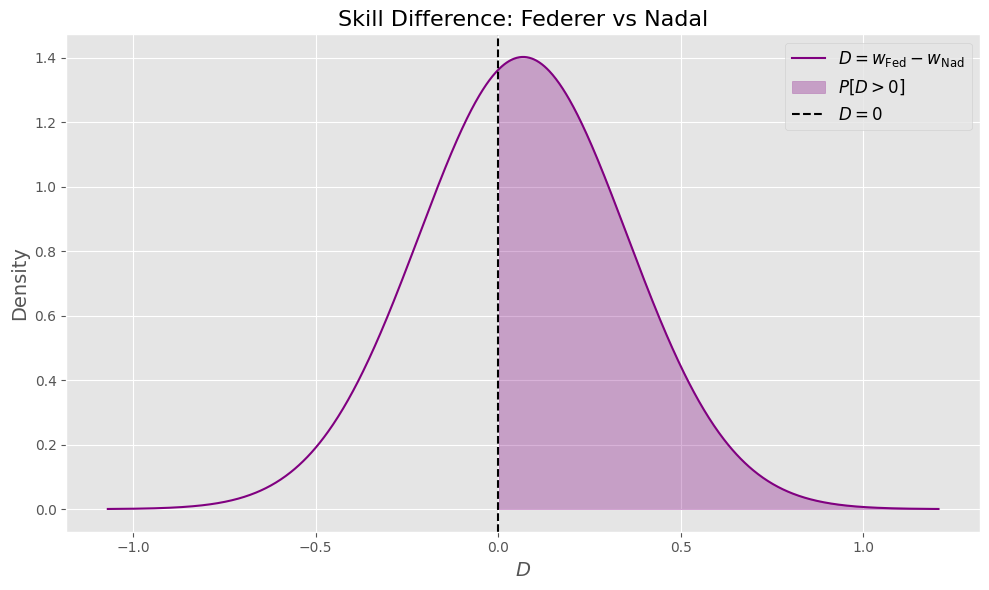

In [102]:
def approximate_gaussian(arr):
    return np.mean(arr, axis=1), np.var(arr, axis=1)

fed_mu, fed_var = approximate_gaussian(thinned_skill_samples[0:1, :])
nad_mu, nad_var = approximate_gaussian(thinned_skill_samples[1:2, :])

# D = Federer - Nadal
D_mu = fed_mu[0] - nad_mu[0]
D_std = np.sqrt(fed_var[0] + nad_var[0])

prob_fed = 1 - norm.cdf(0, loc=D_mu, scale=D_std)
print("p(Federer more skilled) =", prob_fed)

# plot skill difference distribution
x = np.linspace(D_mu - 4*D_std, D_mu + 4*D_std, 1000)
pdf = norm.pdf(x, loc=D_mu, scale=D_std)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, color="purple", label=r"$D = w_{\rm Fed} - w_{\rm Nad}$")
plt.fill_between(x, pdf, where=(x >= 0), color="purple", alpha=0.3, label=r"$P[D > 0]$")
plt.axvline(0, color="black", ls="--", label="$D=0$")
plt.title("Skill Difference: Federer vs Nadal", fontsize=16)
plt.xlabel(r"$D$", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [103]:
#sample based approach
skill_diff = thinned_skill_samples[0] - thinned_skill_samples[1]
p = np.mean(skill_diff > 0)
print("Probability of federer having larger skill =", p)

Probability of federer having larger skill = 0.6167664670658682


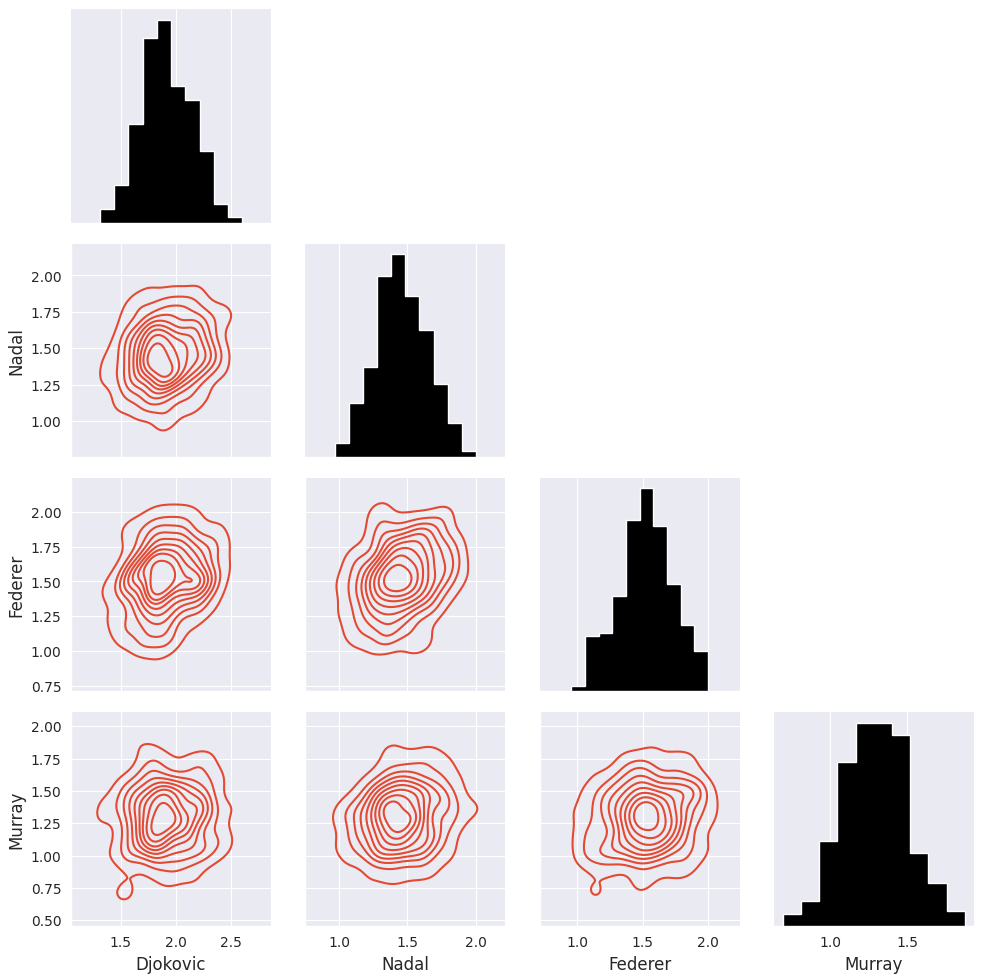

In [104]:
thinned_skill_samples = skill_samples[top4, burn_in::thinning]
data = pd.DataFrame(thinned_skill_samples.T, columns = ["Djokovic", "Nadal", "Federer", "Murray"])

with sns.axes_style("darkgrid"):
    g = sns.PairGrid(data, diag_sharey=False, corner=True)
    g.map_lower(sns.kdeplot, n_levels = 10)
    g.map_diag(plt.hist, linewidth=1, histtype='stepfilled', color='black')
    
fig.tight_layout()
plt.show()

# Comparison of Player Rankings

``` 
    Here we will compare the rankings of players based on the average probability of winning.
    This can be done according to the following:
        1. Empirical win probability 
        2. Gibbs sampling win probability
        3. Message passing win probability
```

In [105]:
def empirical_win_probability(G, M):
    return np.array([np.sum(G[:, 0] == p) / np.sum(G == p) for p in range(M)])

def win_prob_gaussian(diffs, variances):
    return norm.cdf(diffs / np.sqrt(variances + 1))

def collapse_win_matrix(matrix, M):
    # average over opponents, centre at 0.5
    return (np.sum(matrix, axis=-1) - 0.5) / (M - 1)

def gibbs_win_probability(samples, M):
    """MC estimate of avg win prob from i.i.d. skill samples (M x n)."""
    win_prob = np.zeros((M, M))
    for means in samples.T:
        diffs = means[:, None] - means[None, :]
        win_prob += win_prob_gaussian(diffs, 0)
    win_prob /= samples.shape[1]
    return collapse_win_matrix(win_prob, M)

def mp_win_probability(means, precis, M):
    """Analytical win prob assuming independent Gaussian skills from EP."""
    diffs = means[:, None] - means[None, :]
    varss = (1/precis)[:, None] + (1/precis)[None, :]
    win_prob = win_prob_gaussian(diffs, varss)
    return collapse_win_matrix(win_prob, M)

empirical_wp = empirical_win_probability(G, M)

thinned_skill_samples = skill_samples[:, burn_in::thinning]
gibbs_wp = gibbs_win_probability(thinned_skill_samples, M)
mp_wp = mp_win_probability(mps, pps, M)

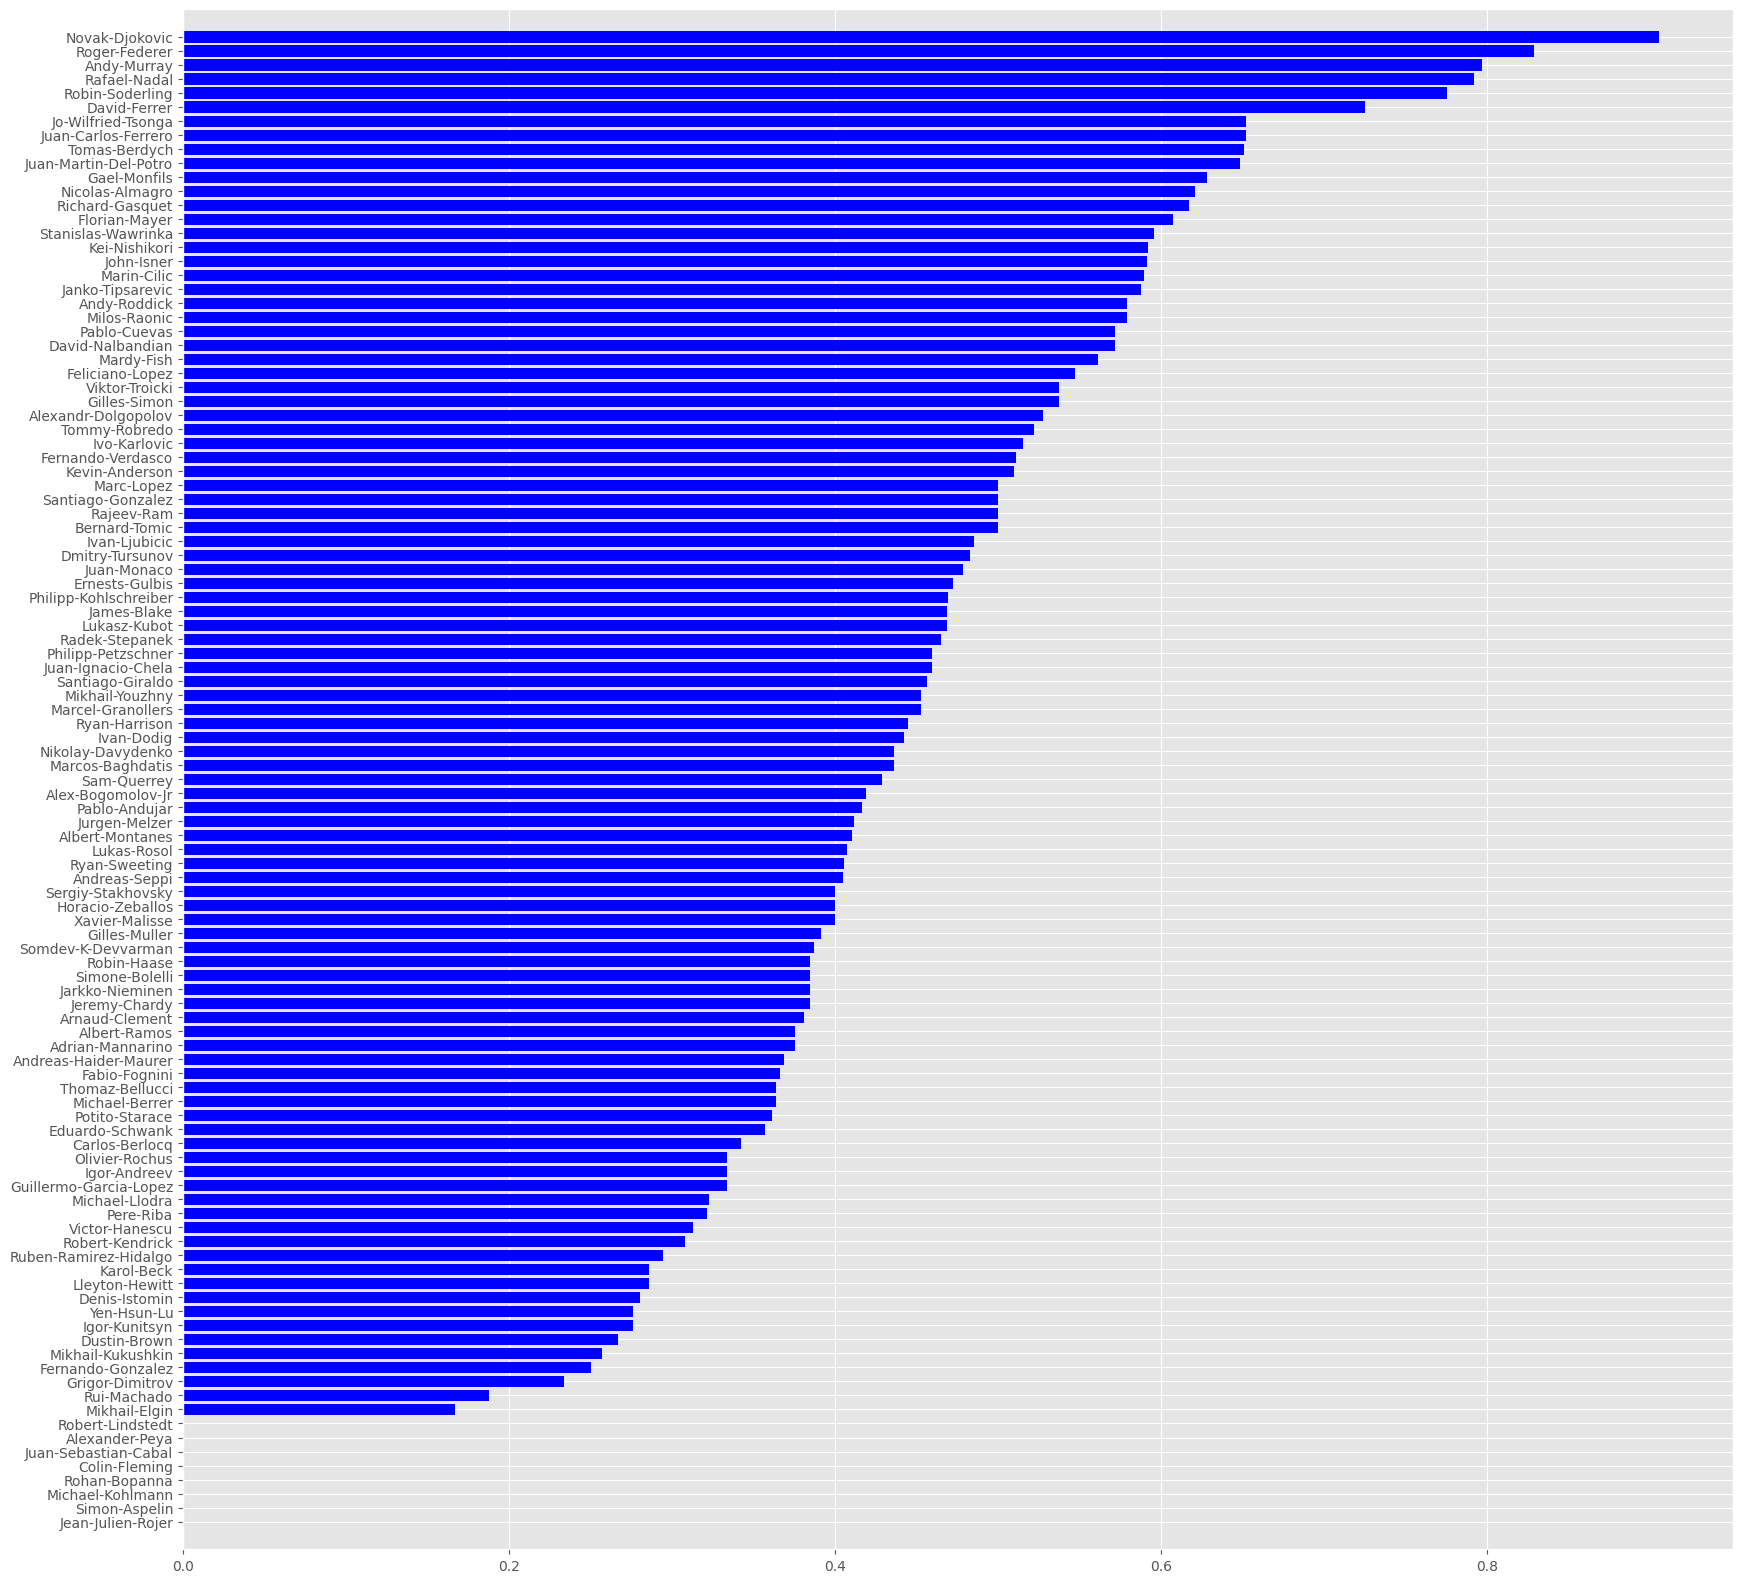

In [106]:
sorted_barplot(empirical_wp, W)
fig.tight_layout()
plt.show()

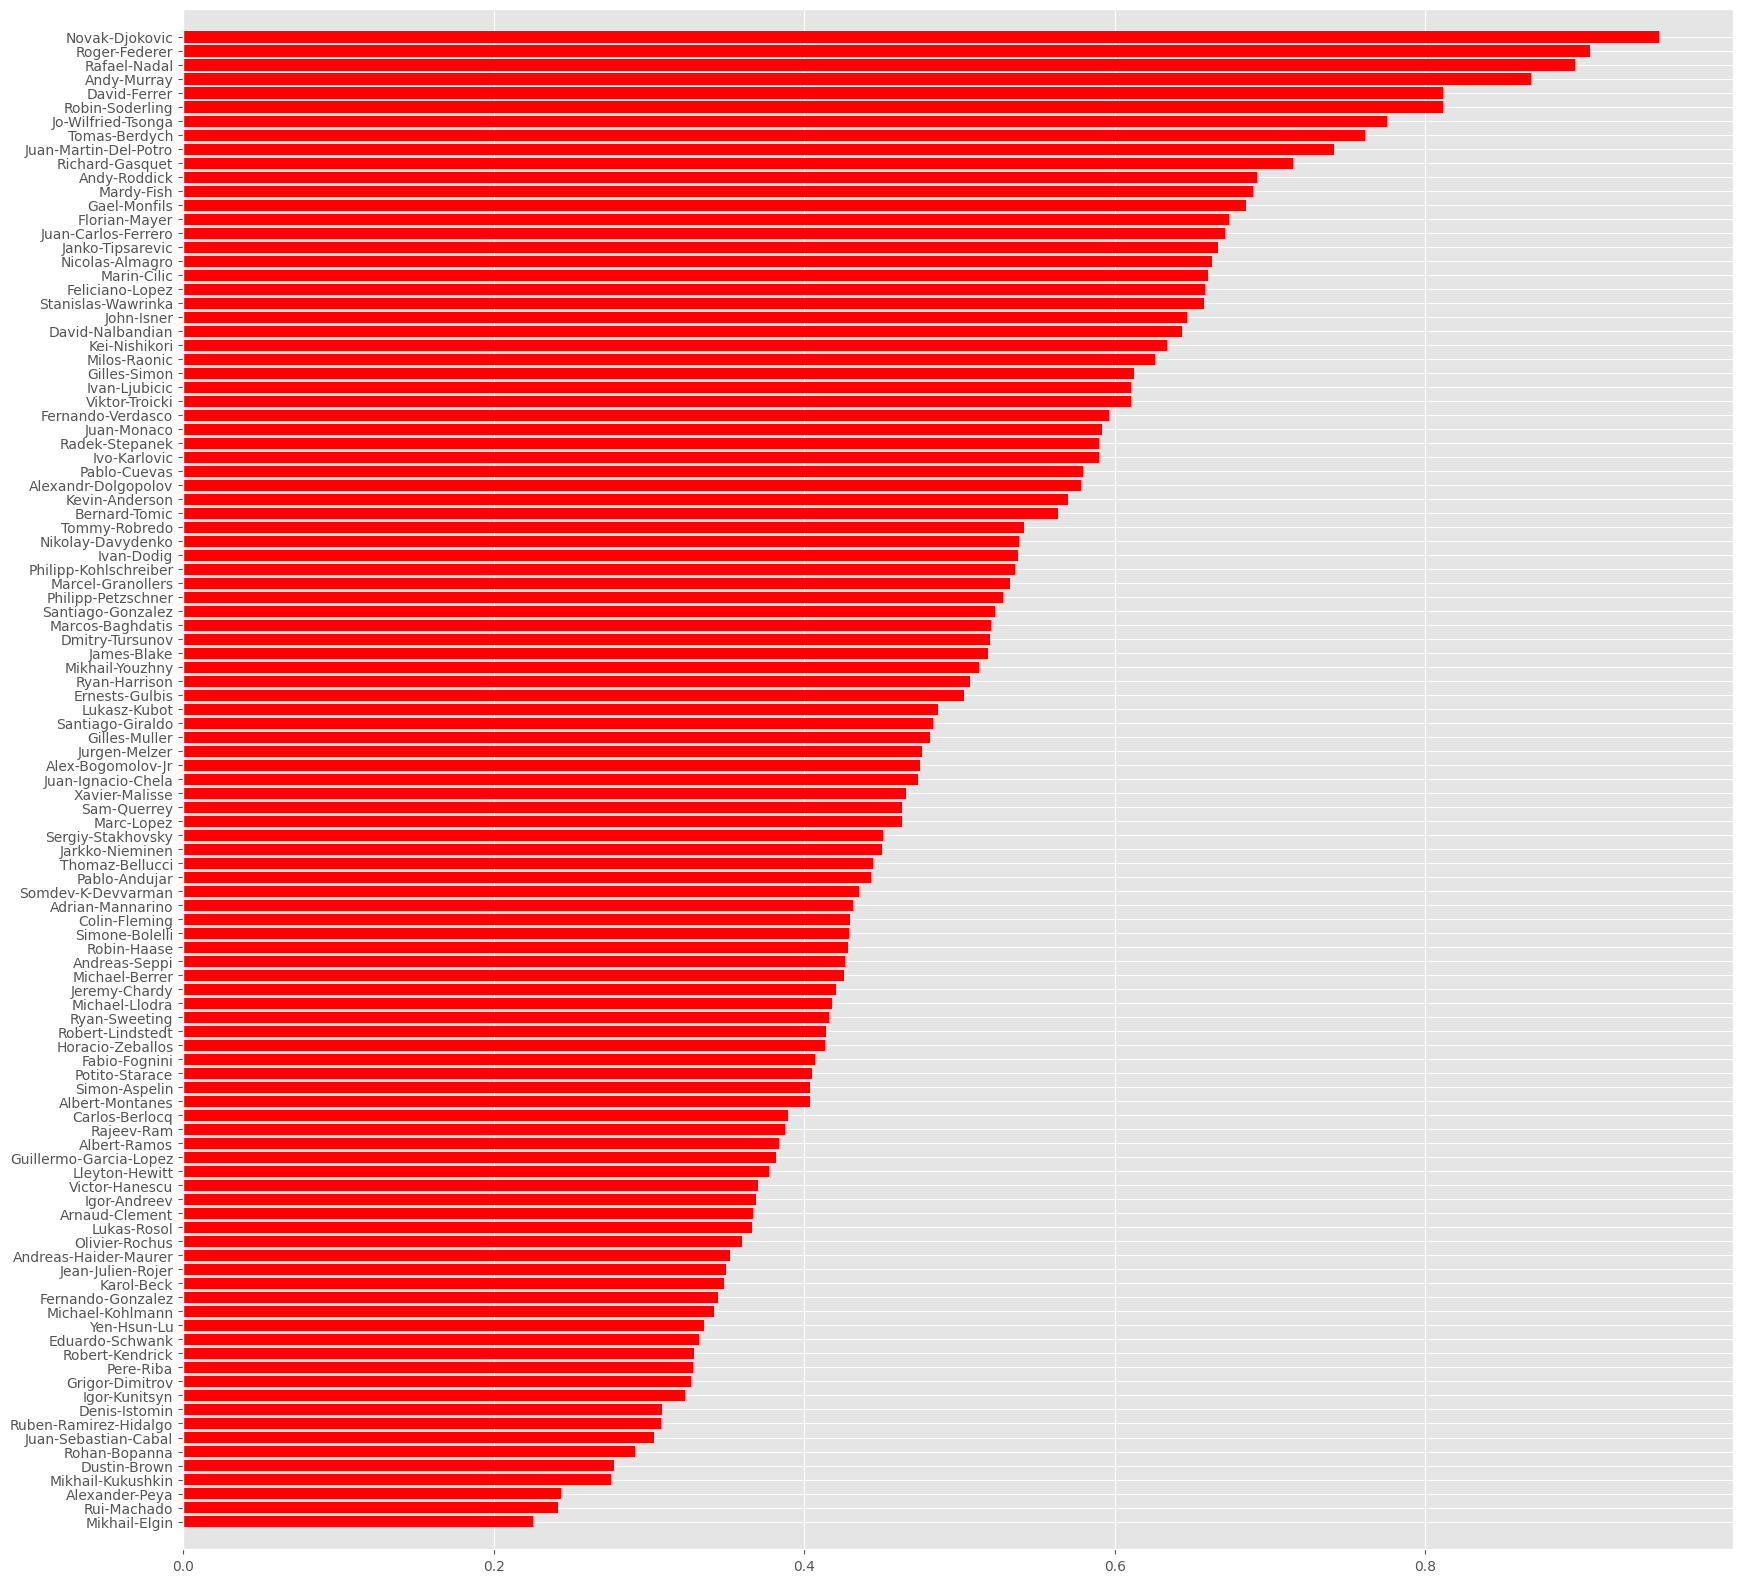

In [107]:
sorted_barplot(gibbs_wp, W, color='red')
fig.tight_layout()
plt.show()

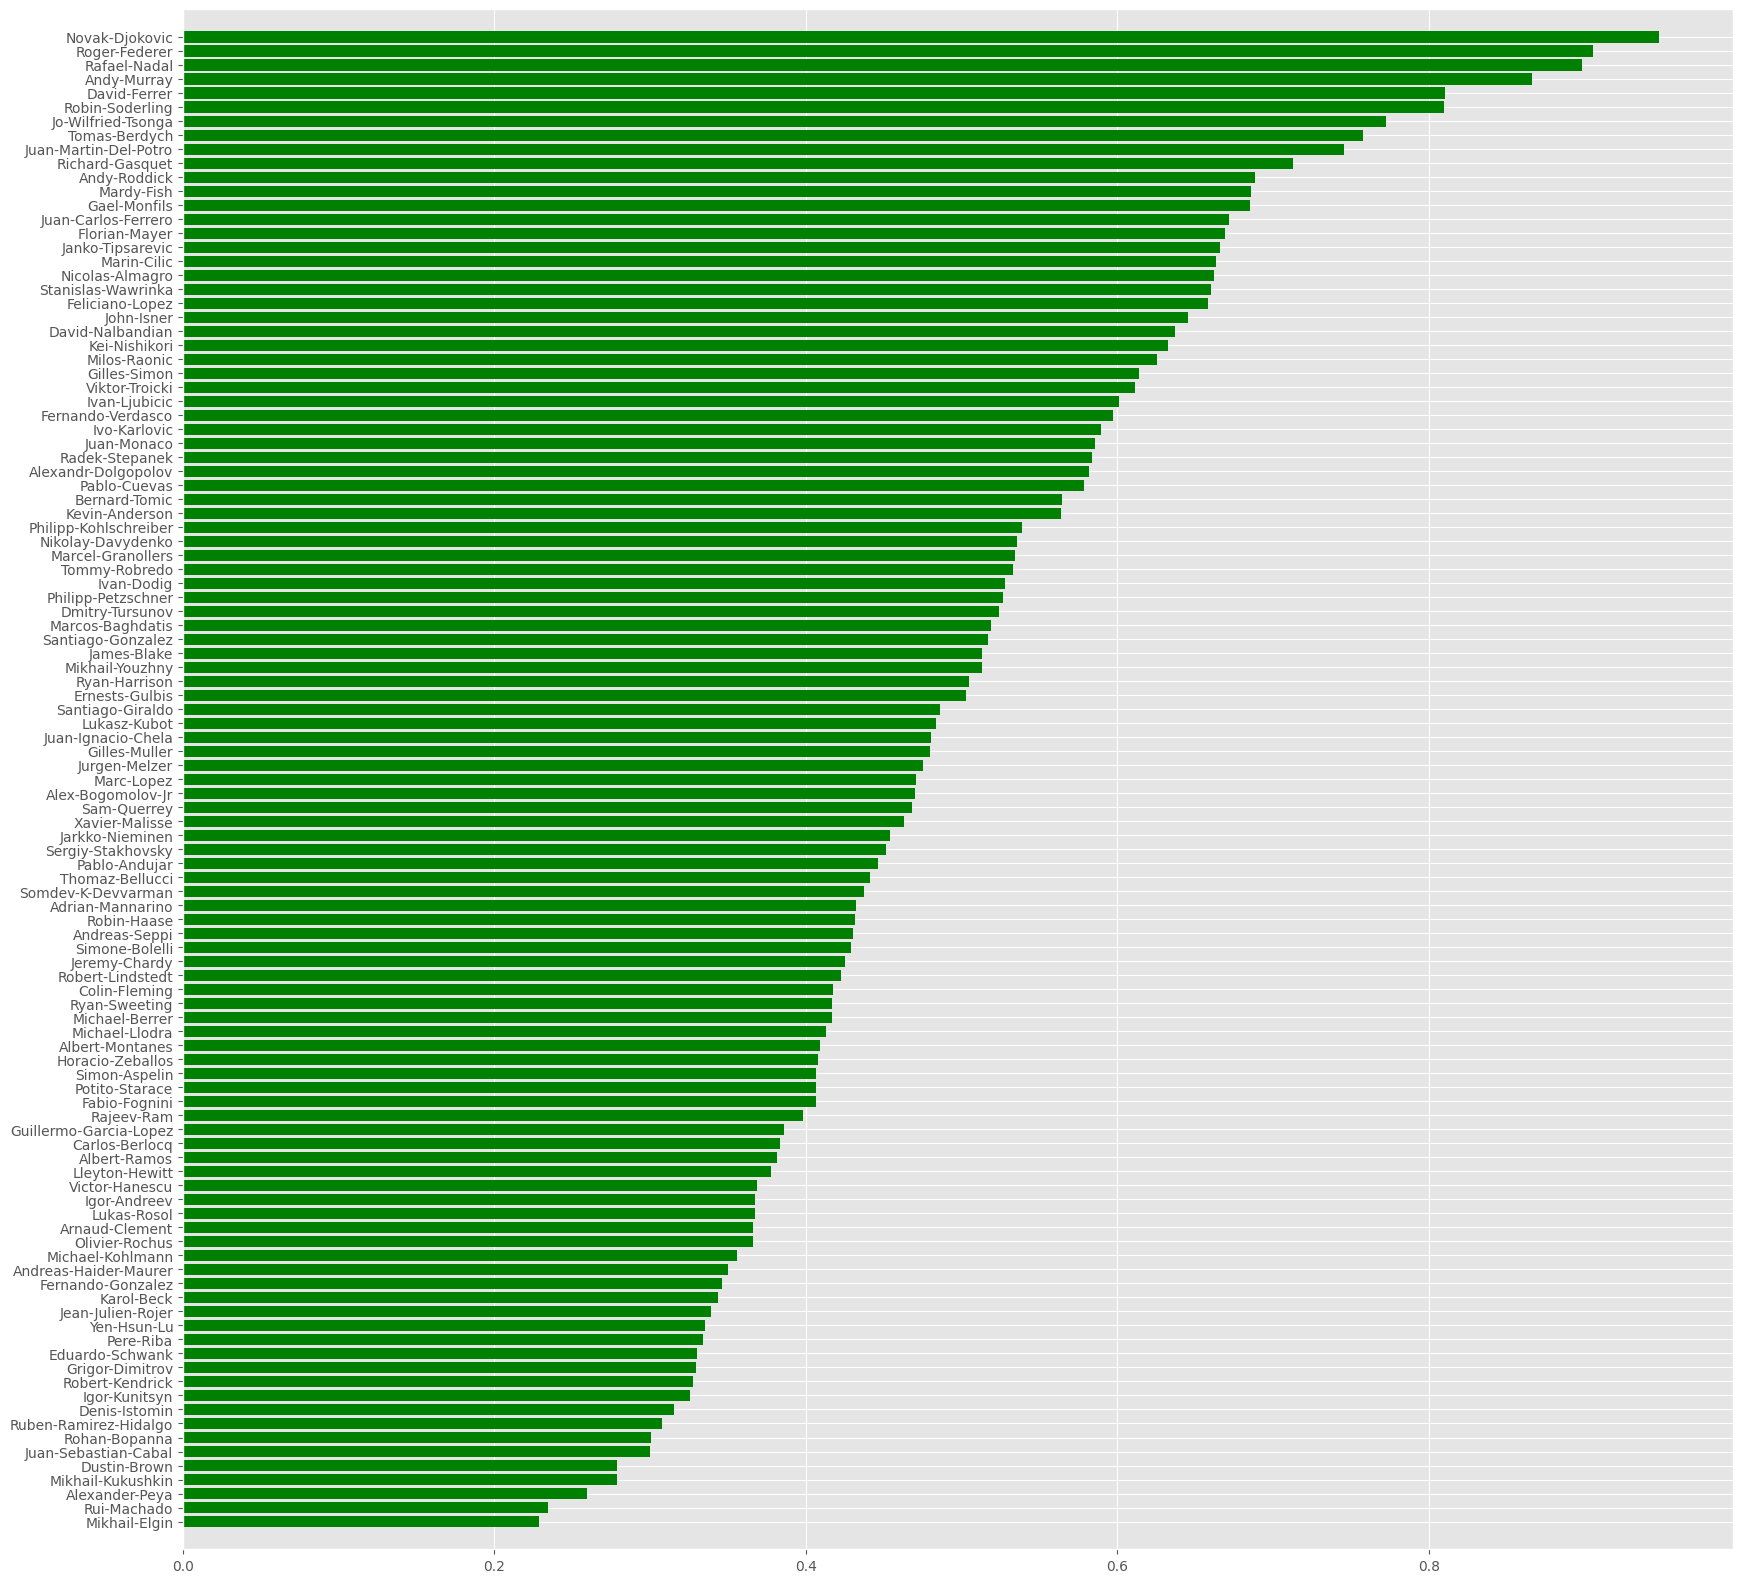

In [108]:
sorted_barplot(mp_wp, W, color='green')
fig.tight_layout()
plt.show()

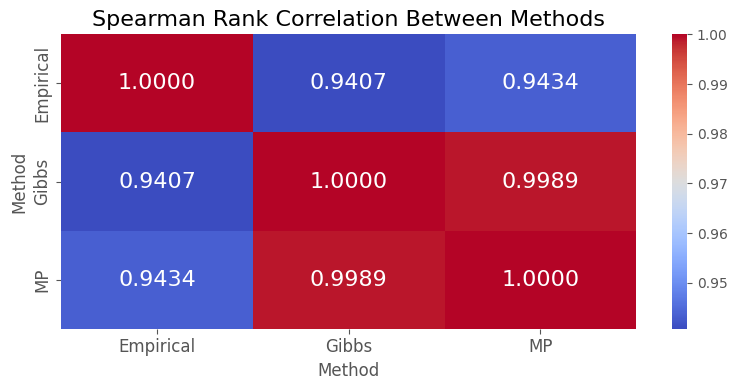

In [ ]:
from scipy.stats import spearmanr, rankdata

empirical_ranking = rankdata(empirical_wp)
gibbs_ranking = rankdata(gibbs_wp)
mp_ranking = rankdata(mp_wp)

# spearman rank correlation between all pairs
spearman = np.zeros((3, 3))
spearman[1, 0] = spearmanr(gibbs_ranking, empirical_ranking).correlation
spearman[2, 0] = spearmanr(mp_ranking, empirical_ranking).correlation
spearman[2, 1] = spearmanr(mp_ranking, gibbs_ranking).correlation
spearman += spearman.T + np.eye(3)

labels = ["Empirical", "Gibbs", "EP"]
plt.figure(figsize=(8, 4))
sns.heatmap(spearman, annot=True, fmt=".4f", xticklabels=labels, yticklabels=labels,
            cmap="coolwarm", annot_kws={"size": 16})
plt.title("Spearman Rank Correlation Between Methods", fontsize=16)
plt.tight_layout()
plt.show()

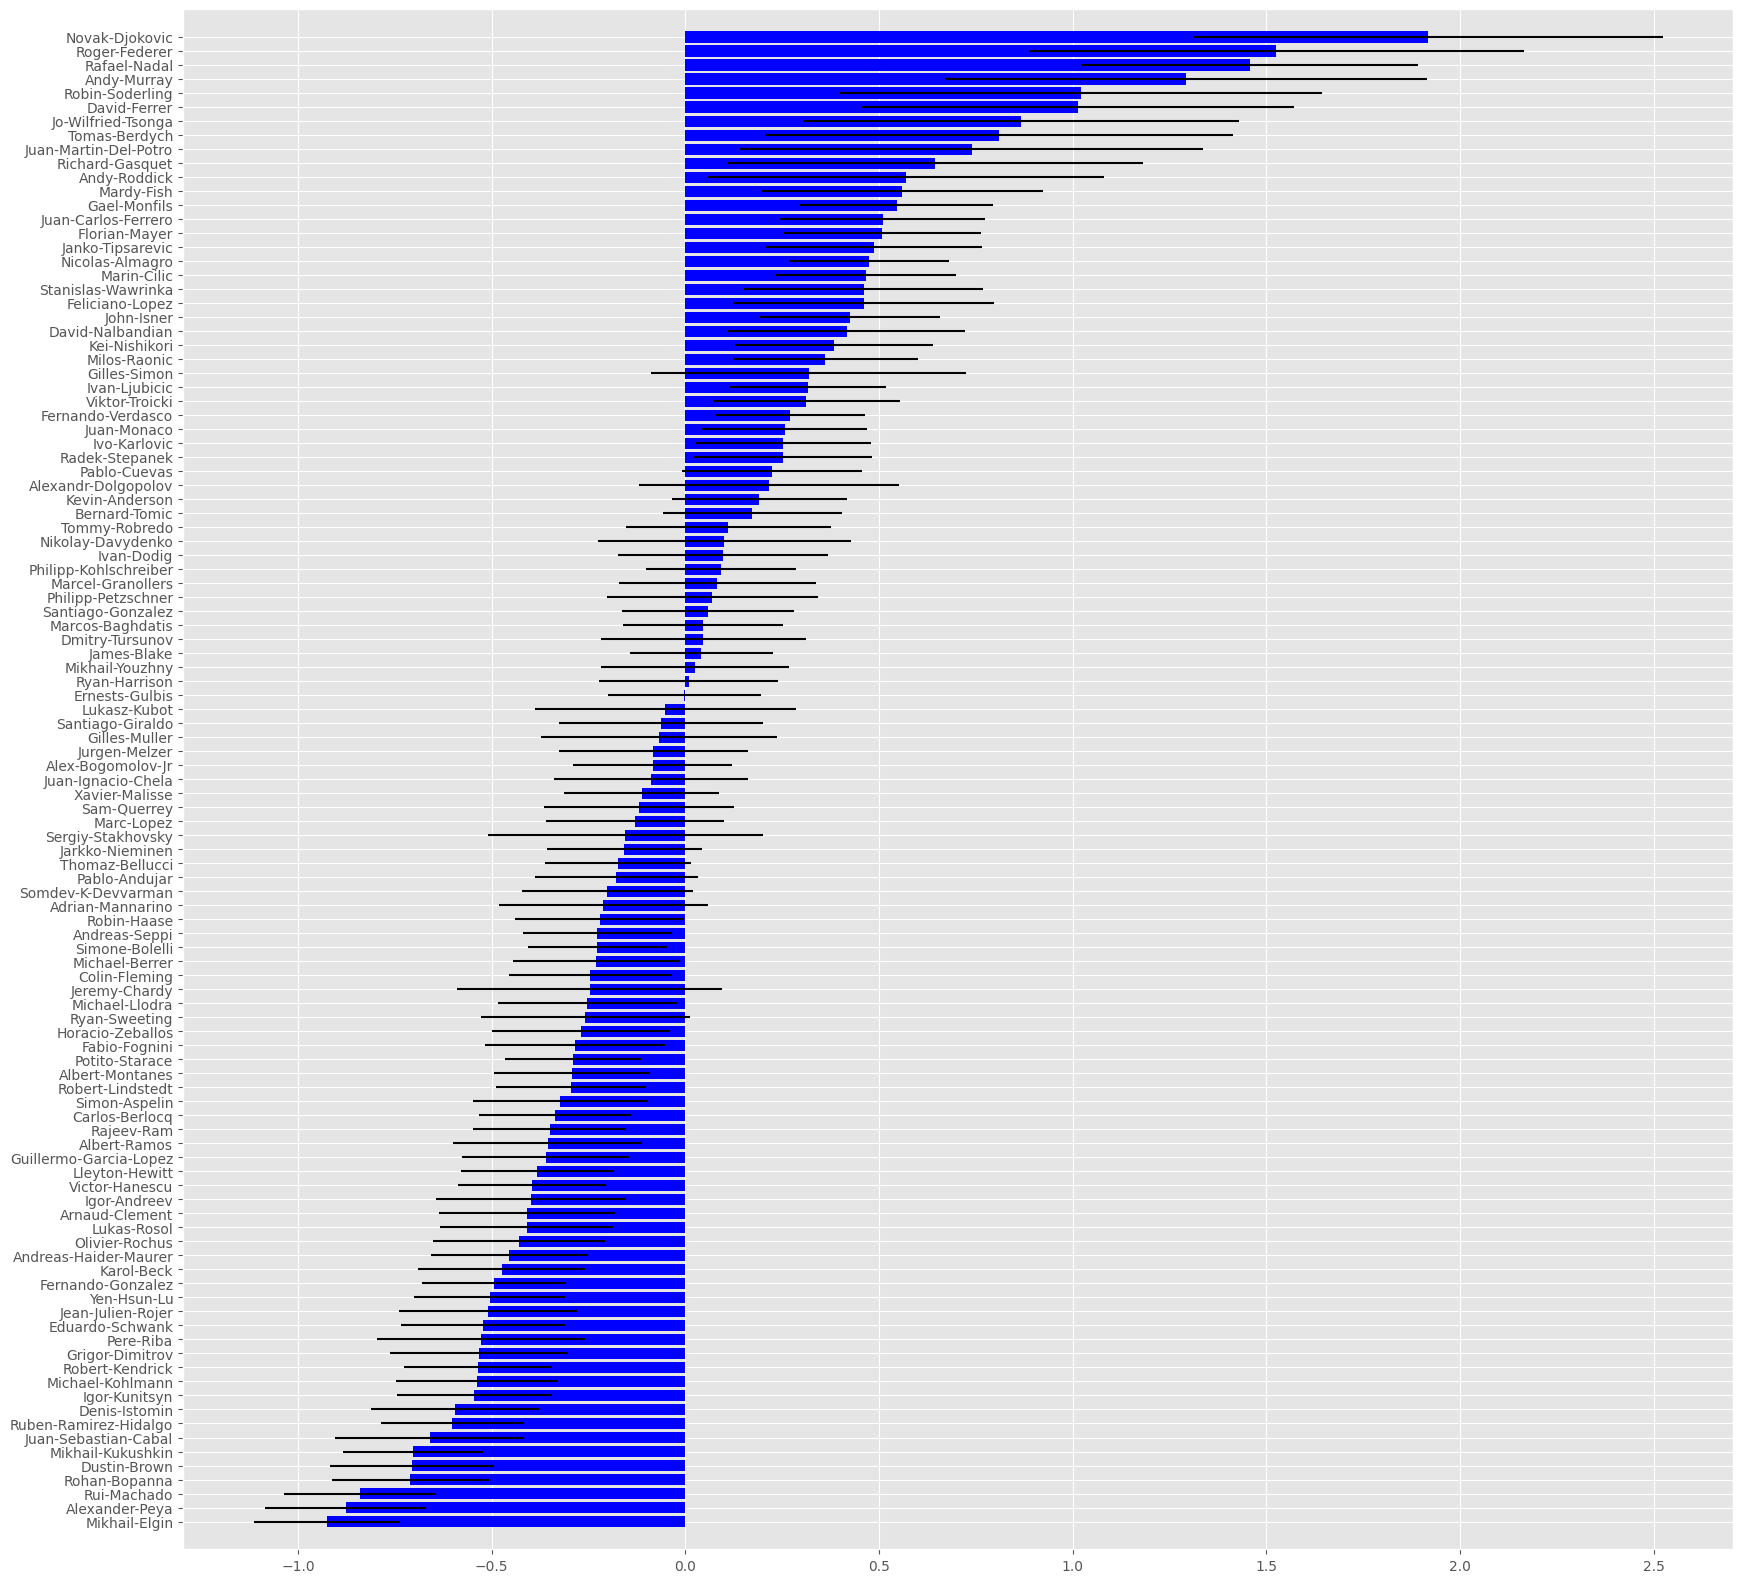

In [ ]:
gibbs_skill = thinned_skill_samples.mean(axis = -1)
sorted_barplot(gibbs_skill, W, E = thinned_skill_samples.std(axis = -1))
fig.tight_layout()
plt.show()

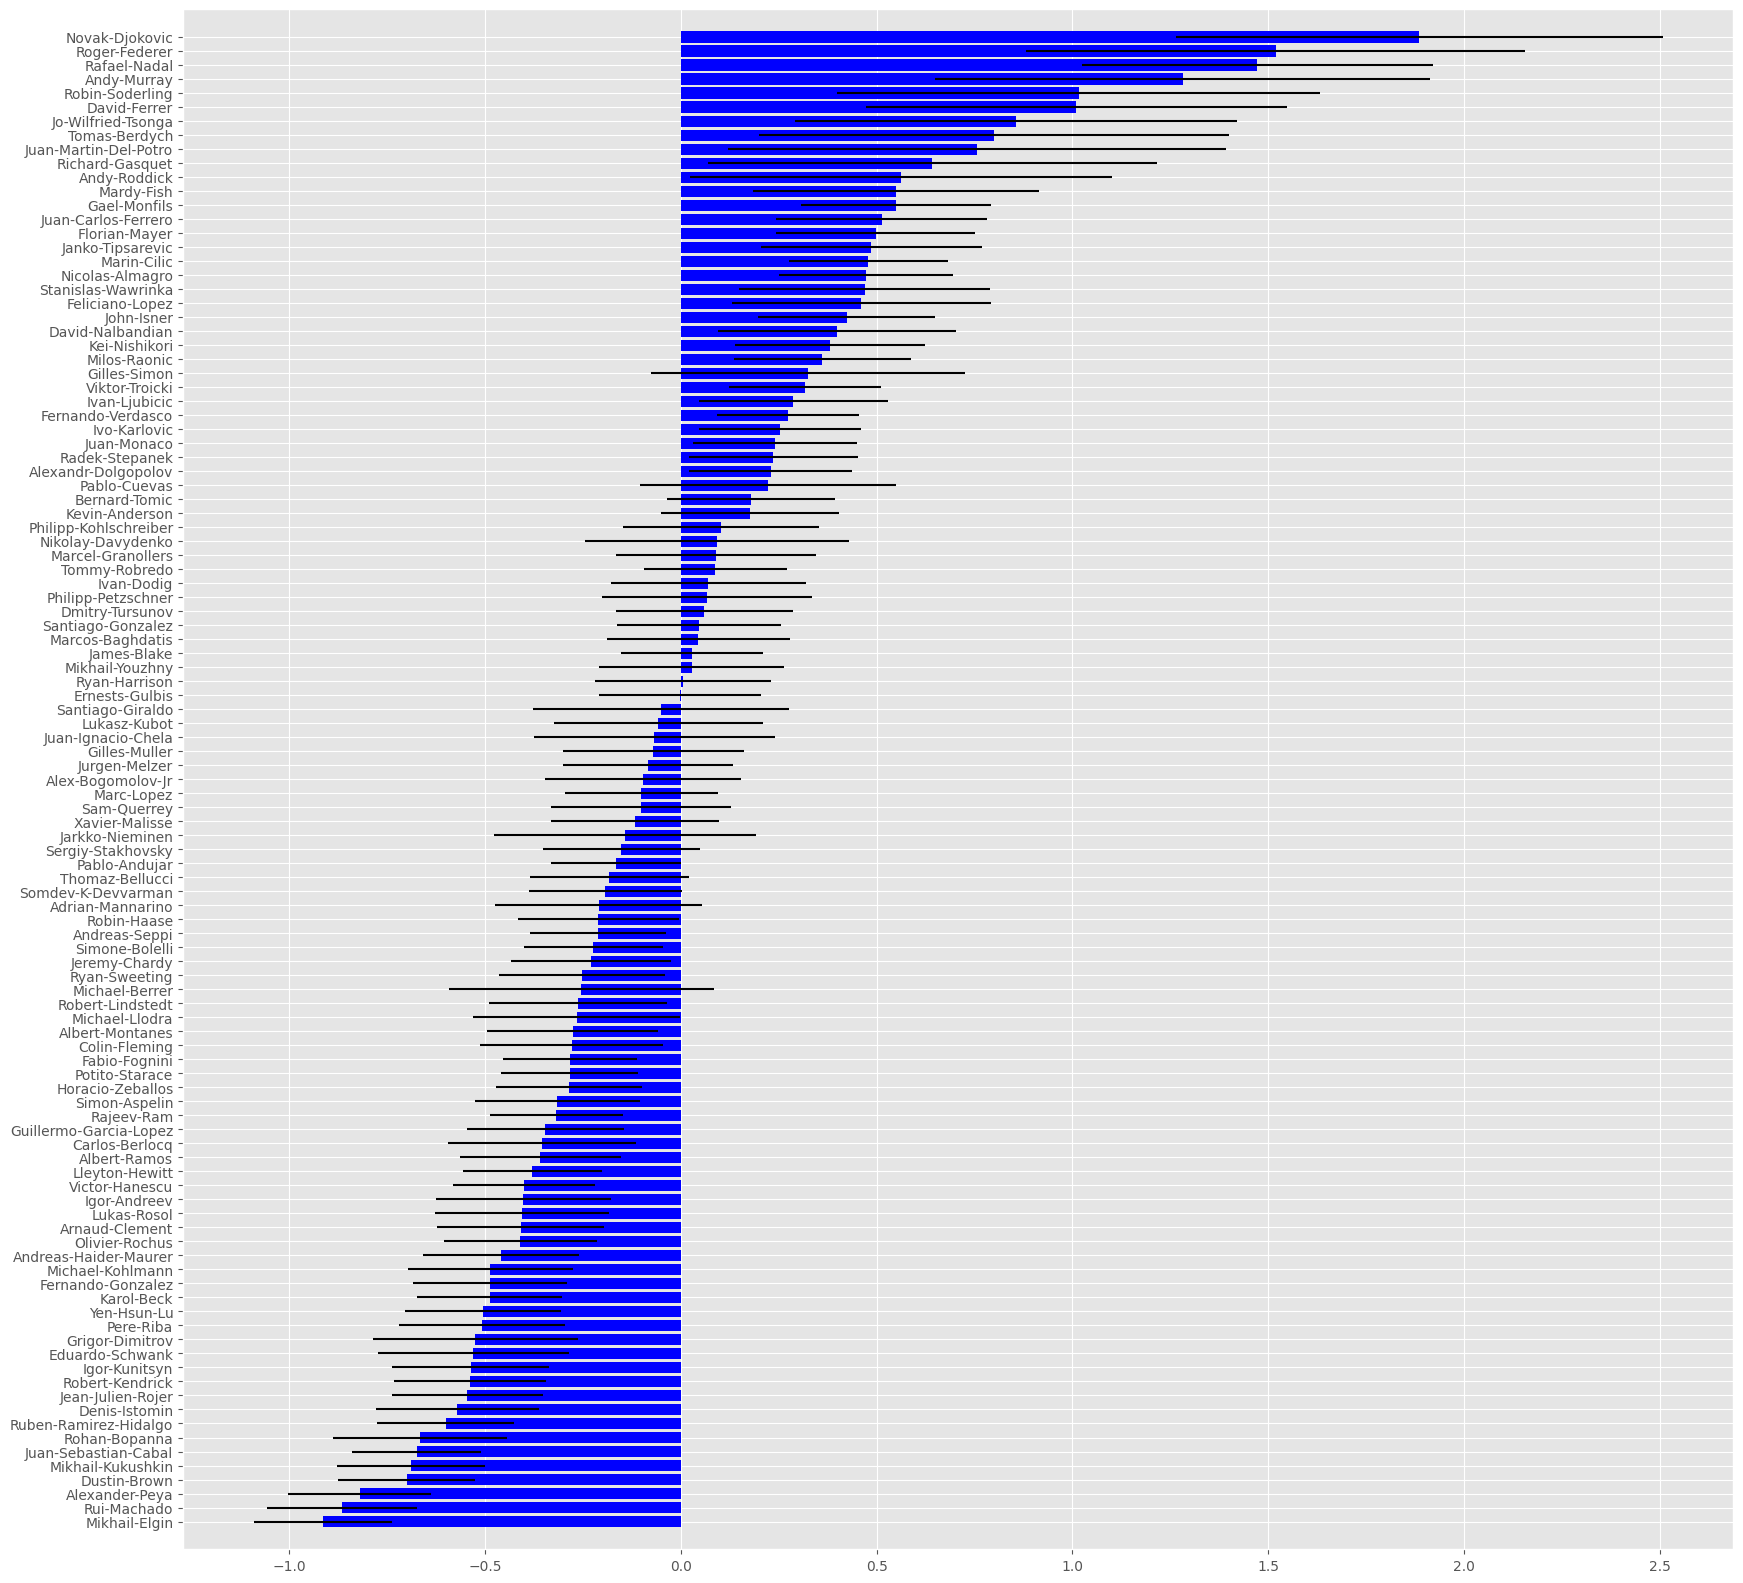

In [ ]:
sorted_barplot(mps, W, E = 1/pps**0.5)
fig.tight_layout()
plt.show()

In [ ]:
# total spearman rankordering
rankings, n = [empirical_wp, gibbs_wp, gibbs_skill, mp_wp, mps], 5

spearman = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        spearman[i, j] = spearmanr(rankings[i], rankings[j]).correlation

spearman.round(4)

array([[1.    , 0.9407, 0.9455, 0.9434, 0.9466],
       [0.9407, 1.    , 0.9994, 0.9989, 0.9982],
       [0.9455, 0.9994, 1.    , 0.9984, 0.9985],
       [0.9434, 0.9989, 0.9984, 1.    , 0.9995],
       [0.9466, 0.9982, 0.9985, 0.9995, 1.    ]])